# Data Augmentation per la Sicurezza delle Centrali Elettriche

## Contesto
Il progetto implementa una pipeline di data augmentation basata su modelli generativi per migliorare un sistema di riconoscimento di immagini applicato alla sorveglianza di infrastrutture critiche (CyberEye Solutions). Il dataset **OxfordIIITPet** è utilizzato come proxy del dominio reale, come da specifica della consegna.

## Pipeline
1. **Image captioning** (BLIP) — descrizioni automatiche delle immagini reali
2. **Text augmentation** (Flan-T5) — varianti semantiche delle caption
3. **Image generation** (FLUX.1-schnell) — immagini sintetiche condizionate sulla razza
4. **Classifier** (ResNet18) — confronto baseline vs augmented

## Struttura
1. Setup e configurazione
2. Preparazione del dataset
3. Training del classificatore baseline
4. Pipeline di generazione dati sintetici
5. Training con dataset aumentato
6. Analisi dei risultati
7. Conclusioni


## 1. Setup e configurazione

### 1.1 Installazione dipendenze

In [ ]:
import importlib
import importlib.util
import subprocess
import sys

def _ensure(pkg_spec, import_name=None):
    module = (import_name or pkg_spec.split("==")[0].split(">=")[0]).replace("-", "_")
    if importlib.util.find_spec(module) is None:
        print(f"Installazione: {pkg_spec}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_spec])

for pkg, mod in [
    ("transformers", None),
    ("diffusers", None),
    ("accelerate", None),
    ("sentencepiece", None),
    ("rouge-score", "rouge_score"),
    ("torchmetrics", None),
    ("torch-fidelity", "torch_fidelity"),
    ("opencv-python", "cv2"),
]:
    _ensure(pkg, mod)
print("Dipendenze pronte.")


Versioni iniziali:
- torch: 2.10.0+cu128
- torchvision: 0.25.0+cu128
- torchaudio: 2.10.0+cu128
Pacchetti core PyTorch gia' presenti: nessuna reinstallazione.
Installo: torchmetrics
Installo: torch-fidelity

Versioni finali:
- transformers: 5.0.0
- diffusers: 0.37.1
- accelerate: 1.13.0
- torchmetrics: 1.9.0

Sono stati installati/aggiornati pacchetti. Se noti errori di import, riavvia il runtime e riesegui da questa cella.


### 1.2 Import e configurazione globale

In [ ]:
import os
import re
import json
import random
import gc
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, models
from torchvision.datasets import OxfordIIITPet

import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
)

from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    AutoTokenizer, AutoModelForSeq2SeqLM,
)
from diffusers import AutoPipelineForText2Image

from rouge_score import rouge_scorer
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.inception import InceptionScore


@dataclass
class CFG:
    # Riproducibilità
    seed: int = 42
    num_workers: int = 2

    # Dataset
    img_size: int = 224
    train_size: int = 1800
    val_size: int = 500
    test_size: int = 1000

    # Classifier training
    batch_size: int = 32
    baseline_epochs: int = 8
    augmented_epochs: int = 15
    lr: float = 2e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.1

    # Captioning (BLIP)
    max_caption_images: int = 800

    # Text augmentation (Flan-T5)
    text_model_name: str = "google/flan-t5-large"
    text_max_new_tokens: int = 64

    # Image generation (FLUX.1-schnell)
    diffusion_model_name: str = "black-forest-labs/FLUX.1-schnell"
    gen_image_size: int = 512
    num_inference_steps: int = 4

    # Strategia sintetici
    augment_all_classes: bool = True
    synthetic_ratio_per_class: float = 0.50
    synthetic_min_per_class: int = 15
    synthetic_max_per_class: int = 25
    max_gen_attempts_per_image: int = 8
    image_hash_hamming_threshold: int = 5

    # Weak class selection (analisi post-hoc)
    weak_recall_threshold: float = 0.75
    weak_f1_threshold: float = 0.75

    # Training augmented
    synth_train_ratio: float = 0.15
    synth_quality_keep_quantile: float = 0.20
    synth_max_per_class_train: int = 40

    # Filtri qualità visiva (tarati per FLUX)
    image_std_low: float = 10.0
    image_std_high: float = 120.0
    image_mean_low: float = 20.0
    image_mean_high: float = 235.0
    image_edge_min: float = 10.0
    image_sat_max: float = 250.0
    image_colorfulness_max: float = 200.0

    # Output
    output_dir: str = "./outputs"


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


cfg = CFG()
set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

for sub in ["captions", "synthetic_images", "metrics"]:
    Path(f"{cfg.output_dir}/{sub}").mkdir(parents=True, exist_ok=True)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
Output dir: ./outputs


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 2. Preparazione del dataset

### 2.1 Download e split stratificato

In [ ]:
raw_trainval = OxfordIIITPet(root="data", split="trainval", target_types="category", download=True)
raw_test = OxfordIIITPet(root="data", split="test", target_types="category", download=True)

y_trainval = np.array([raw_trainval[i][1] for i in range(len(raw_trainval))])
y_test_all = np.array([raw_test[i][1] for i in range(len(raw_test))])

train_idx, val_idx = train_test_split(
    np.arange(len(raw_trainval)),
    test_size=min(cfg.val_size, len(raw_trainval) // 3),
    random_state=cfg.seed,
    stratify=y_trainval,
)
if len(train_idx) > cfg.train_size:
    train_idx, _ = train_test_split(
        train_idx, train_size=cfg.train_size, random_state=cfg.seed, stratify=y_trainval[train_idx]
    )
if len(val_idx) > cfg.val_size:
    val_idx, _ = train_test_split(
        val_idx, train_size=cfg.val_size, random_state=cfg.seed, stratify=y_trainval[val_idx]
    )

test_idx = np.arange(len(raw_test))
if len(test_idx) > cfg.test_size:
    test_idx, _ = train_test_split(
        test_idx, train_size=cfg.test_size, random_state=cfg.seed, stratify=y_test_all[test_idx]
    )

num_classes = int(max(y_trainval.max(), y_test_all.max()) + 1)
class_names = [str(n).replace("_", " ") for n in raw_trainval.classes]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)} | Classi: {num_classes}")


100%|██████████| 792M/792M [00:03<00:00, 235MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 123MB/s] 


Train: 1800 Val: 500 Test: 1000 Classes: 37


### 2.2 Transform e DataLoader

In [ ]:
train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class PetSubsetDataset(Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base_ds = base_ds
        self.indices = np.array(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base_ds[int(self.indices[i])]
        return self.transform(img), int(label)


class SyntheticImageDataset(Dataset):
    def __init__(self, manifest_df, transform):
        self.df = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row.path).convert("RGB")
        return self.transform(img), int(row.label)


train_ds = PetSubsetDataset(raw_trainval, train_idx, train_tfms)
val_ds = PetSubsetDataset(raw_trainval, val_idx, eval_tfms)
test_ds = PetSubsetDataset(raw_test, test_idx, eval_tfms)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, pin_memory=True)


### 2.3 Visualizzazione campioni reali

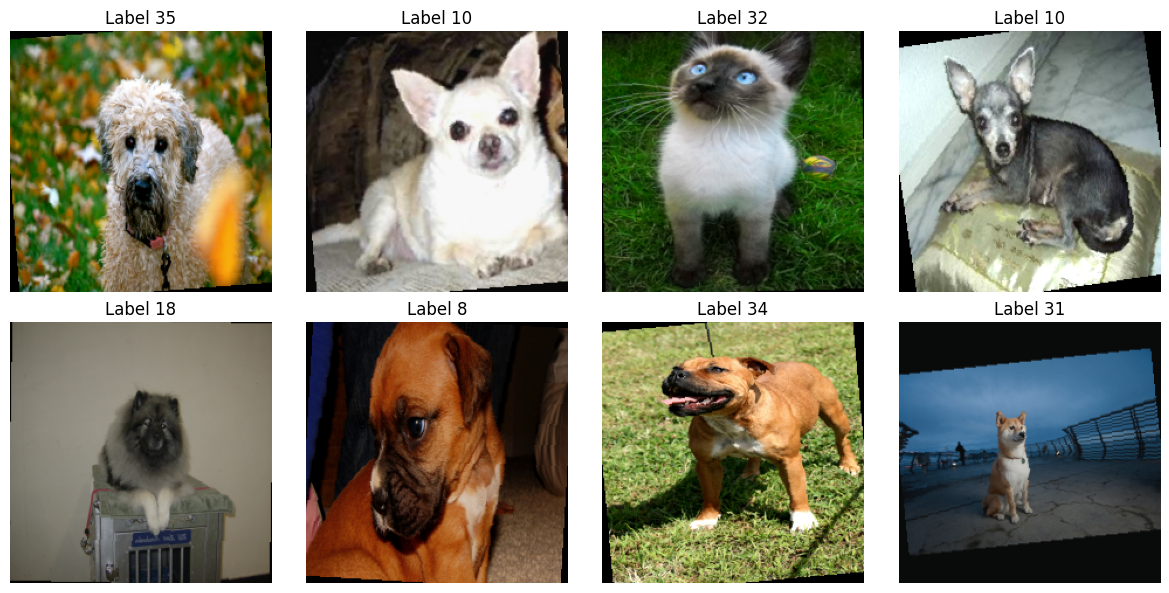

In [ ]:
inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    x = inv_norm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(np.clip(x, 0, 1))
    ax.set_title(class_names[int(labels[i])], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Training del classificatore baseline

### 3.1 Architettura e utilità di training

In [ ]:
def build_model(n_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses, y_true, y_pred = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        losses.append(loss.item())
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "loss": float(np.mean(losses)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(p), "recall": float(r), "f1": float(f1),
        "y_true": y_true, "y_pred": y_pred,
    }


def train_model(train_loader, val_loader, epochs, seed=None):
    """Addestra il classifier selezionando il miglior modello sulla validation."""
    if seed is not None:
        set_seed(int(seed))
    model = build_model(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_acc, best_state, history = -1.0, None, []
    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)
        history.append({"epoch": epoch, "train": tr, "val": va})
        print(f"Epoch {epoch}/{epochs} | train_acc={tr['accuracy']:.4f} | "
              f"val_acc={va['accuracy']:.4f} | val_f1={va['f1']:.4f}")
        if va["accuracy"] > best_acc:
            best_acc = va["accuracy"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, history


def evaluate(model, loader):
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    return run_epoch(model, loader, criterion, optimizer=None)


### 3.2 Training del baseline

In [ ]:
baseline_model, baseline_history = train_model(
    train_loader, val_loader, cfg.baseline_epochs, seed=cfg.seed
)
baseline_test = evaluate(baseline_model, test_loader)

print("\nBaseline — metriche sul test set")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {k}: {baseline_test[k]:.4f}")

baseline_report_df = pd.DataFrame(
    classification_report(baseline_test["y_true"], baseline_test["y_pred"],
                          output_dict=True, zero_division=0)
).T
class_mask = baseline_report_df.index.to_series().astype(str).str.fullmatch(r"\d+")
baseline_report_df[class_mask].to_csv(
    f"{cfg.output_dir}/metrics/baseline_classification_report.csv", index_label="class_id"
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Epoch 1/8 | train_acc=0.5778 | val_acc=0.8100 | val_f1=0.8081
Epoch 2/8 | train_acc=0.9044 | val_acc=0.8260 | val_f1=0.8216
Epoch 3/8 | train_acc=0.9661 | val_acc=0.8360 | val_f1=0.8366
Epoch 4/8 | train_acc=0.9856 | val_acc=0.8640 | val_f1=0.8645
Epoch 5/8 | train_acc=0.9878 | val_acc=0.8420 | val_f1=0.8398
Epoch 6/8 | train_acc=0.9922 | val_acc=0.8480 | val_f1=0.8467
Epoch 7/8 | train_acc=0.9956 | val_acc=0.8580 | val_f1=0.8586
Epoch 8/8 | train_acc=0.9961 | val_acc=0.8560 | val_f1=0.8561
Baseline metrics
accuracy: 0.8450
precision: 0.8516
recall: 0.8443
f1: 0.8426
Weak classes (baseline): [34, 2, 1, 20, 6, 26, 10, 23, 5, 0, 9, 27]


### 3.3 Confusion matrix del baseline

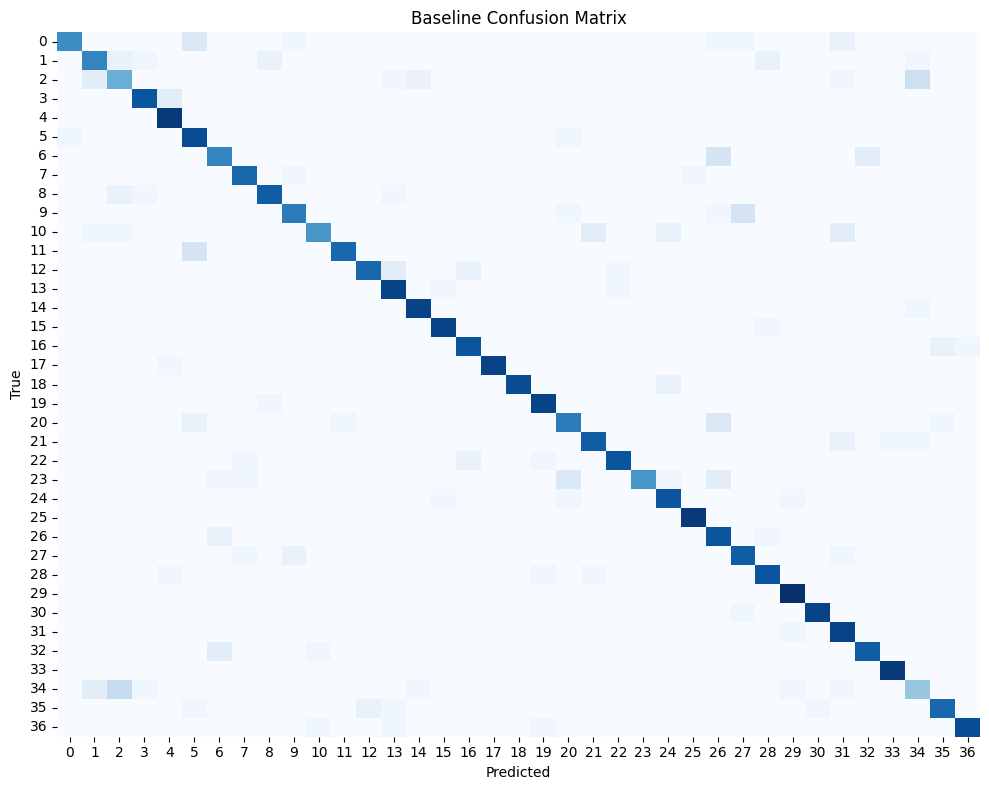

In [ ]:
cm_base = confusion_matrix(baseline_test["y_true"], baseline_test["y_pred"])
plt.figure(figsize=(10, 8))
sns.heatmap(cm_base, cmap="Blues", cbar=False)
plt.title("Confusion matrix — Baseline")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 4. Pipeline di generazione dati sintetici

La generazione sintetica segue quattro stadi:

1. **Captioning** delle immagini reali con BLIP
2. **Paraphrasing** delle caption con Flan-T5 per aumentare la diversità testuale
3. **Caricamento della pipeline FLUX.1-schnell** in bfloat16
4. **Generazione** condizionata sulla razza, con filtri di qualità e deduplicazione


### 4.1 Image captioning (BLIP)

In [ ]:
captions_path = f"{cfg.output_dir}/captions/captions.csv"

if os.path.exists(captions_path):
    captions_df = pd.read_csv(captions_path)
    print(f"Caption caricate da cache: {len(captions_df)} righe")
else:
    caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    caption_model = BlipForConditionalGeneration.from_pretrained(
        "Salesforce/blip-image-captioning-base"
    ).to(device)
    caption_model.eval()

    cap_indices = train_idx[:min(cfg.max_caption_images, len(train_idx))]
    caption_rows = []
    for idx in tqdm(cap_indices, desc="Captioning"):
        image, label = raw_trainval[int(idx)]
        inputs = caption_processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            out = caption_model.generate(**inputs, max_new_tokens=25)
        cap = caption_processor.decode(out[0], skip_special_tokens=True).strip()
        caption_rows.append({"source_idx": int(idx), "label": int(label), "caption": cap})

    captions_df = pd.DataFrame(caption_rows)
    captions_df.to_csv(captions_path, index=False)
    print(f"Caption generate: {len(captions_df)} — salvate in {captions_path}")

    del caption_model, caption_processor
    gc.collect()
    torch.cuda.empty_cache()

captions_df.head()


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Captioning:   0%|          | 0/800 [00:00<?, ?it/s]

Caption generate e salvate in: ./outputs/captions/captions.csv
Numero caption generate: 800


,source_idx,label,caption
0,767,15,a small white dog running through a dirt cover...
1,3574,34,a dog laying on a bed
2,2923,21,a small dog standing on a beach next to a person
3,2728,17,a small black and white dog sitting in the grass
4,1567,31,a small dog with a black nose and brown eyes


### 4.2 Text augmentation (Flan-T5)

In [ ]:
texts_path = f"{cfg.output_dir}/captions/captions_paraphrases.csv"


def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9 ,.\'-]", "", x)
    return x


def token_overlap(a, b):
    ta = set(t for t in re.findall(r"[a-z0-9\']+", clean_text(a)) if len(t) > 1)
    tb = set(t for t in re.findall(r"[a-z0-9\']+", clean_text(b)) if len(t) > 1)
    return len(ta & tb) / max(1, len(ta | tb)) if (ta and tb) else 0.0


if os.path.exists(texts_path):
    texts_df = pd.read_csv(texts_path)
    print(f"Paraphrase caricate da cache: {len(texts_df)} righe")
else:
    text_tokenizer = AutoTokenizer.from_pretrained(cfg.text_model_name)
    text_model = AutoModelForSeq2SeqLM.from_pretrained(
        cfg.text_model_name, torch_dtype=torch.float32
    ).to(device)
    text_model.eval()

    def generate_paraphrase(caption):
        prompt = f"Paraphrase this pet description in a different wording: {caption}"
        inputs = text_tokenizer(prompt, return_tensors="pt", truncation=True,
                                max_length=128).to(device)
        with torch.no_grad():
            out = text_model.generate(
                **inputs,
                max_new_tokens=cfg.text_max_new_tokens,
                do_sample=True, top_p=0.92, temperature=0.85,
                num_return_sequences=1,
            )
        return text_tokenizer.decode(out[0], skip_special_tokens=True).strip()

    rows = []
    stats = {"total": 0, "accepted": 0, "fallback": 0}
    for _, r in tqdm(captions_df.iterrows(), total=len(captions_df), desc="Text augmentation"):
        stats["total"] += 1
        cap = str(r["caption"])
        try:
            par = generate_paraphrase(cap)
        except Exception:
            par = cap
        overlap = token_overlap(cap, par)
        if len(par.split()) < 3 or overlap > 0.9 or overlap < 0.1:
            par = cap
            stats["fallback"] += 1
        else:
            stats["accepted"] += 1
        rows.append({
            "source_idx": int(r["source_idx"]),
            "label": int(r["label"]),
            "caption": cap,
            "paraphrase": par,
        })

    texts_df = pd.DataFrame(rows)
    texts_df.to_csv(texts_path, index=False)
    print(f"Paraphrase: {stats['accepted']} accettate, {stats['fallback']} fallback su originale")

    del text_model, text_tokenizer
    gc.collect()
    torch.cuda.empty_cache()

texts_df.head()


Provo a caricare text model: google/flan-t5-large


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Text model richiesto: google/flan-t5-large
Text model in uso: google/flan-t5-large


Text augmentation:   0%|          | 0/800 [00:00<?, ?it/s]

Paraphrase generate e salvate in: ./outputs/captions/captions_paraphrases.csv
Pipeline testo in uso: modello generativo + template
Caption iniziali: 800 | Prompt finali unici: 800
Combinazioni template disponibili per classe: 80
Text stats: {'total': 800, 'accepted': 753, 'fallback_generation_error': 0, 'fallback_quality_filter': 47, 'used_original_caption': 47}
Acceptance rate: 94.12% | Fallback rate: 5.88%


,source_idx,label,caption,paraphrase
696,618,12,a dog sitting on a couch,a close-up photograph of english cocker spanie...
667,3293,29,a white dog walking down the sidewalk,"a candid photo of samoyed in its environment, ..."
63,1235,24,a small dog sitting in the back seat of a car,a snapshot of pomeranian from a real-world set...
533,2524,13,a dog with its tongue out,a high-quality pet photograph of english sette...
66,2779,18,a dog laying on the floor,"a candid photo of keeshond in its environment,..."


### 4.3 Valutazione qualità paraphrase (ROUGE)

In [ ]:
_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

sample_n = min(500, len(texts_df))
subset = texts_df.sample(n=sample_n, random_state=42).reset_index(drop=True)
rows = []
for _, r in subset.iterrows():
    s = _rouge.score(str(r["caption"]), str(r["paraphrase"]))
    rows.append({k: s[k].fmeasure for k in ["rouge1", "rouge2", "rougeL"]})
rouge_df = pd.DataFrame(rows)

rouge_summary = rouge_df.mean().to_frame("mean").join(rouge_df.std().to_frame("std"))
print("ROUGE F1 medio tra caption e paraphrase:")
print(rouge_summary.round(4).to_string())

rouge_df.to_csv(f"{cfg.output_dir}/captions/paraphrase_rouge_scores.csv", index=False)

rL = rouge_summary.loc["rougeL", "mean"]
diag = ("coerenza semantica ottimale" if 0.25 <= rL <= 0.60
        else "troppa divergenza" if rL < 0.25 else "scarsa variazione")
print(f"\nROUGE-L medio {rL:.3f} — {diag}")


ROUGE paraphrase (caption originale → paraphrase generata):
            mean     std
rouge1_f  0.4616  0.0854
rouge2_f  0.2802  0.1072
rougeL_f  0.4402  0.0888

Interpretazione ROUGE-L medio:
  0.440 — Range ottimale: buona diversita' con coerenza semantica


### 4.4 Caricamento pipeline FLUX.1-schnell

In [ ]:
print(f"Caricamento pipeline: {cfg.diffusion_model_name}")
pipe = AutoPipelineForText2Image.from_pretrained(
    cfg.diffusion_model_name,
    torch_dtype=torch.bfloat16,
).to(device)
pipe.set_progress_bar_config(disable=True)
print("Pipeline pronta.")


Caricamento pipeline: black-forest-labs/FLUX.1-schnell


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline pronta.
use_clip_filter: False, soglia CLIP: 0.0


### 4.5 Generazione immagini sintetiche

Per ogni classe target, il sistema genera prompt della forma `"a photo of a {nome razza}, {paraphrase}"`. L'iniezione esplicita del nome della razza è critica: BLIP produce caption generiche (es. *"a small dog"*), quindi senza questo passaggio FLUX non avrebbe modo di generare immagini razza-specifiche.

Ogni immagine generata passa attraverso:
- **Filtri qualità visiva** (deviazione standard, media, edge variance, saturazione, colorfulness)
- **Deduplicazione** tramite perceptual hash

La strategia attuale augmenta **tutte le classi** in modo proporzionale per evitare class imbalance artificiale.

In [ ]:
_STYLE_TEMPLATES = [
    "high quality realistic photo, {core}, natural colors, balanced contrast, DSLR",
    "real-world candid pet photo, {core}, soft daylight, natural tones, photorealistic",
    "documentary style animal photography, {core}, neutral saturation, detailed fur texture",
    "clean realistic pet image, {core}, outdoor ambient light, true-to-life colors",
    "editorial wildlife-like pet portrait, {core}, cinematic but natural grading",
]


def make_style_prompt(core_prompt):
    return random.choice(_STYLE_TEMPLATES).format(core=core_prompt)


def image_fingerprint(img):
    gray = img.convert("L").resize((9, 8), Image.Resampling.BILINEAR)
    arr = np.array(gray, dtype=np.float32)
    diff = arr[:, 1:] > arr[:, :-1]
    return "".join("1" if x else "0" for x in diff.flatten())


def hamming(a, b):
    return sum(ch1 != ch2 for ch1, ch2 in zip(a, b)) if len(a) == len(b) else 999


def colorfulness_score(arr):
    arr = arr.astype(np.float32)
    rg = np.abs(arr[:, :, 0] - arr[:, :, 1])
    yb = np.abs(0.5 * (arr[:, :, 0] + arr[:, :, 1]) - arr[:, :, 2])
    return float(np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2) +
                 0.3 * np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2))


def quality_checks(img):
    arr = np.array(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    std = float(np.std(arr))
    mean = float(np.mean(arr))
    edge = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    sat = float(np.mean(cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)[:, :, 1]))
    colorfulness = colorfulness_score(arr)
    ok = (
        cfg.image_std_low <= std <= cfg.image_std_high
        and cfg.image_mean_low <= mean <= cfg.image_mean_high
        and edge >= cfg.image_edge_min
        and sat <= cfg.image_sat_max
        and colorfulness <= cfg.image_colorfulness_max
    )
    return ok, std, mean, edge, sat, colorfulness


train_labels_list = [int(y_trainval[i]) for i in train_idx]
class_to_idx = {name: i for i, name in enumerate(class_names)}

if cfg.augment_all_classes:
    target_classes = list(class_names)
else:
    weak_df = baseline_report_df[
        baseline_report_df.index.to_series().astype(str).str.fullmatch(r"\d+")
    ].copy()
    weak_df["class_id"] = weak_df.index.astype(int)
    weak_df["class"] = weak_df["class_id"].map(lambda i: class_names[i])
    target_classes = weak_df[
        (weak_df["recall"] < cfg.weak_recall_threshold) |
        (weak_df["f1-score"] < cfg.weak_f1_threshold)
    ]["class"].tolist()

print(f"Classi target per generazione: {len(target_classes)}")

label_to_indices = {}
for i, y in enumerate(train_labels_list):
    label_to_indices.setdefault(y, []).append(i)

synth_records, error_records = [], []
rejection_stats = {"quality": 0, "duplicate": 0, "exception": 0}

for cname in target_classes:
    lbl = class_to_idx[cname]
    class_size = len(label_to_indices.get(lbl, []))
    if class_size == 0:
        continue

    target = int(np.clip(
        class_size * cfg.synthetic_ratio_per_class,
        cfg.synthetic_min_per_class,
        cfg.synthetic_max_per_class,
    ))

    class_rows = texts_df[texts_df["label"] == lbl]
    if len(class_rows) == 0:
        continue

    existing_hashes, accepted, attempts = [], 0, 0
    max_total_attempts = max(target * cfg.max_gen_attempts_per_image, target)

    for _ in tqdm(range(max_total_attempts), desc=f"Synth {cname}"):
        if accepted >= target:
            break
        attempts += 1

        row = class_rows.sample(1, random_state=cfg.seed + attempts).iloc[0]
        base_prompt = str(row["paraphrase"])
        breed_prompt = f"a photo of a {cname}, {base_prompt}"
        prompt = make_style_prompt(breed_prompt)

        try:
            out = pipe(
                prompt=prompt,
                guidance_scale=0.0,
                num_inference_steps=cfg.num_inference_steps,
                height=cfg.gen_image_size,
                width=cfg.gen_image_size,
            )
            img = out.images[0].convert("RGB")

            ok, std, mean, edge, sat, colorfulness = quality_checks(img)
            if not ok:
                rejection_stats["quality"] += 1
                continue

            fp = image_fingerprint(img)
            if any(hamming(fp, prev) <= cfg.image_hash_hamming_threshold for prev in existing_hashes):
                rejection_stats["duplicate"] += 1
                continue

            out_path = f"{cfg.output_dir}/synthetic_images/{cname}_synth_{accepted:04d}.jpg"
            img.save(out_path, quality=95)
            synth_records.append({
                "path": out_path, "label": lbl, "class_name": cname,
                "prompt": prompt, "paraphrase": base_prompt,
                "std": std, "mean": mean, "edge": edge, "sat": sat,
                "colorfulness": colorfulness, "attempt": attempts,
                "fingerprint": fp,
            })
            existing_hashes.append(fp)
            accepted += 1
            torch.cuda.empty_cache()

        except Exception as e:
            rejection_stats["exception"] += 1
            if len(error_records) < 30:
                error_records.append({
                    "class_name": cname, "attempt": attempts,
                    "error": f"{type(e).__name__}: {e}",
                })
            torch.cuda.empty_cache()

synth_df = pd.DataFrame(synth_records)
synth_df.to_csv(f"{cfg.output_dir}/synthetic_images/synth_metadata.csv", index=False)

print(f"\nSintetiche accettate: {len(synth_df)}")
print(f"Scarti: {rejection_stats}")
if len(synth_df) > 0:
    print(f"Qualità media | std: {synth_df['std'].mean():.1f} "
          f"mean: {synth_df['mean'].mean():.1f} "
          f"edge: {synth_df['edge'].mean():.1f} "
          f"sat: {synth_df['sat'].mean():.1f} "
          f"colorfulness: {synth_df['colorfulness'].mean():.1f}")


Modalita: augment TUTTE le classi ( 37 )


Synth Abyssinian:   0%|          | 0/176 [00:00<?, ?it/s]

Synth American Bulldog:   0%|          | 0/176 [00:00<?, ?it/s]

Synth American Pit Bull Terrier:   0%|          | 0/176 [00:00<?, ?it/s]

Synth Basset Hound:   0%|          | 0/176 [00:00<?, ?it/s]

...

Synth Staffordshire Bull Terrier:   0%|          | 0/176 [00:00<?, ?it/s]

Synth Wheaten Terrier:   0%|          | 0/176 [00:00<?, ?it/s]

Synth Yorkshire Terrier:   0%|          | 0/176 [00:00<?, ?it/s]

Sintetiche generate: 814
Scarti synth: {'quality': 0, 'clip': 0, 'duplicate': 0, 'exception': 0}
Qualita' media synth | std: 57.44 mean: 114.79 edge: 897.33 sat: 78.56 colorfulness: 36.69

Controllo umano immagini - sample metadata:


,class_name,path,std,mean,edge,sat,colorfulness,clip_score,attempt
0,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,49.196812,144.673508,477.243878,52.723728,37.458252,NaN,1
1,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,53.689948,153.491114,1014.223268,81.337364,46.314766,NaN,2
2,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,52.211731,153.081801,324.375018,51.786816,32.224930,NaN,3
3,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,55.325155,103.445555,761.152351,68.548298,35.510181,NaN,4
4,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,39.190257,68.443136,615.642435,74.891960,25.670475,NaN,5
5,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,57.280239,105.762383,395.029716,92.302540,43.412277,NaN,6
6,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,59.296170,148.445906,509.257094,69.654842,37.130981,NaN,7
7,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,52.333554,117.510988,378.893085,56.500084,32.882988,NaN,8
8,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,60.817284,128.966482,1116.458822,65.091557,33.937042,NaN,9
9,Abyssinian,./outputs/synthetic_images/Abyssinian_synth_00...,55.680312,132.317145,610.727210,56.579784,27.363811,NaN,10


## 5. Training con dataset aumentato

### 5.1 Liberazione memoria GPU

In [ ]:
for _var in ["pipe"]:
    if _var in globals() and globals()[_var] is not None:
        del globals()[_var]

gc.collect()
torch.cuda.empty_cache()
free_gb = torch.cuda.mem_get_info()[0] / 1e9 if device.type == "cuda" else 0.0
print(f"Memoria GPU libera: {free_gb:.1f} GB")


Memoria GPU libera dopo cleanup: 41.6 GB


### 5.2 Selezione sintetici e training

Le immagini sintetiche vengono filtrate per qualità (top 80% per `quality_score`) e bilanciate per classe. Al training viene aggiunta una quota pari al 15% del training reale, per mantenere basso il rischio di distorsione delle decision boundary.

In [ ]:
if len(synth_df) == 0:
    raise RuntimeError("Nessuna immagine sintetica disponibile per il training augmented.")

synth_pool = synth_df.copy().reset_index(drop=True)

std_s = 1.0 - np.clip(np.abs(synth_pool["std"] - 55.0) / 55.0, 0.0, 1.0)
mean_s = 1.0 - np.clip(np.abs(synth_pool["mean"] - 125.0) / 125.0, 0.0, 1.0)
edge_s = np.clip(synth_pool["edge"] / max(1.0, float(synth_pool["edge"].quantile(0.90))), 0.0, 1.0)
synth_pool["quality_score"] = 0.35 * std_s + 0.35 * mean_s + 0.30 * edge_s

q_thr = float(synth_pool["quality_score"].quantile(cfg.synth_quality_keep_quantile))
synth_pool = synth_pool[synth_pool["quality_score"] >= q_thr]
synth_pool = (
    synth_pool.sort_values(["class_name", "quality_score"], ascending=[True, False])
    .groupby("class_name", as_index=False).head(cfg.synth_max_per_class_train)
    .reset_index(drop=True)
)

max_synth = max(1, int(len(train_ds) * cfg.synth_train_ratio))
use_n = min(max_synth, len(synth_pool))
use_synth_df = synth_pool.sample(n=use_n, random_state=cfg.seed).reset_index(drop=True)

print(f"Train reali: {len(train_ds)}")
print(f"Synth generate: {len(synth_df)} -> dopo filtro: {len(synth_pool)} -> in training: {len(use_synth_df)} "
      f"({100.0 * len(use_synth_df) / len(train_ds):.1f}% del train reale)")

synth_train_ds = SyntheticImageDataset(use_synth_df, train_tfms)
aug_train_ds = ConcatDataset([train_ds, synth_train_ds])
aug_train_loader = DataLoader(aug_train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True)

aug_model, aug_history = train_model(aug_train_loader, val_loader, cfg.augmented_epochs, seed=cfg.seed)
aug_test = evaluate(aug_model, test_loader)

print("\nAugmented — metriche sul test set")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {k}: {aug_test[k]:.4f}")


Train real: 1800
Synth disponibili prima filtro: 814
Synth dopo filtro qualita'+bilanciamento: 651
Train synth usate: 270 (15.0% del train reale)
Epoch 1/15 | train_acc=0.5700 | val_acc=0.7760 | val_f1=0.7708
Epoch 2/15 | train_acc=0.8932 | val_acc=0.7980 | val_f1=0.7974
Epoch 3/15 | train_acc=0.9628 | val_acc=0.8560 | val_f1=0.8556
Epoch 4/15 | train_acc=0.9845 | val_acc=0.8580 | val_f1=0.8553
Epoch 5/15 | train_acc=0.9899 | val_acc=0.8400 | val_f1=0.8402
Epoch 6/15 | train_acc=0.9942 | val_acc=0.8300 | val_f1=0.8311
Epoch 7/15 | train_acc=0.9957 | val_acc=0.8180 | val_f1=0.8222
Epoch 8/15 | train_acc=0.9961 | val_acc=0.8520 | val_f1=0.8535
Epoch 9/15 | train_acc=0.9990 | val_acc=0.8600 | val_f1=0.8600
Epoch 10/15 | train_acc=0.9986 | val_acc=0.8600 | val_f1=0.8591
Epoch 11/15 | train_acc=0.9990 | val_acc=0.8620 | val_f1=0.8610
Epoch 12/15 | train_acc=1.0000 | val_acc=0.8620 | val_f1=0.8637
Epoch 13/15 | train_acc=0.9995 | val_acc=0.8620 | val_f1=0.8599
Epoch 14/15 | train_acc=0.9986 

## 6. Analisi dei risultati

### 6.1 Confronto globale baseline vs augmented

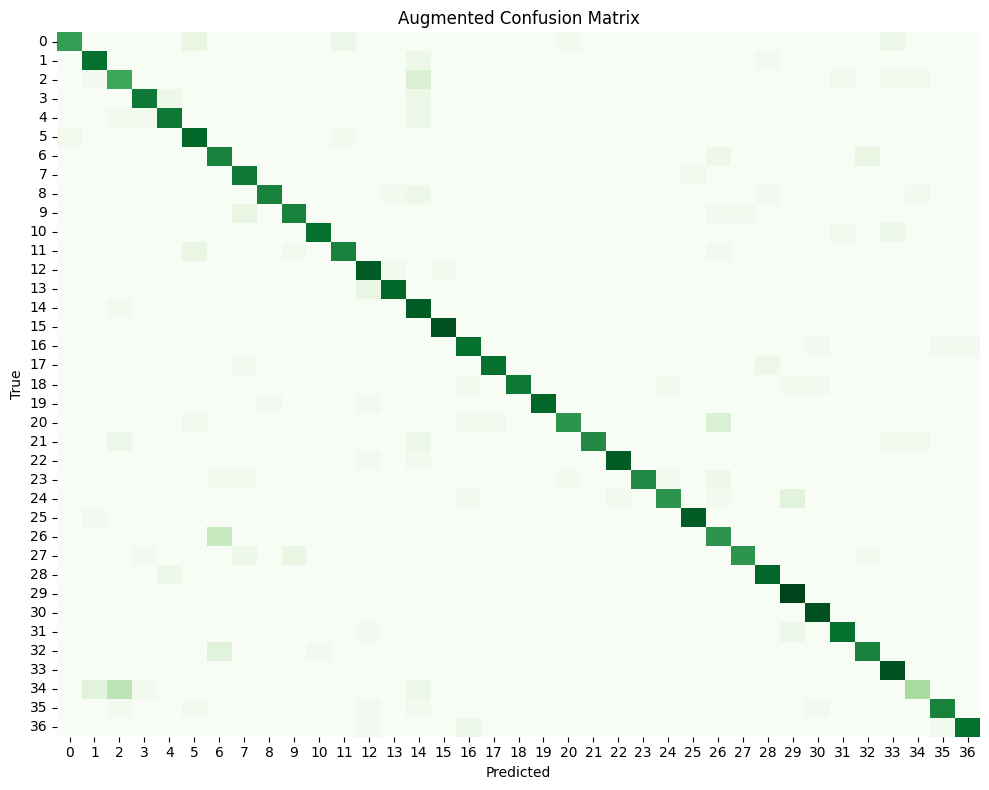

Classification report baseline
              precision    recall  f1-score   support

           0       0.95      0.67      0.78        27
           1       0.73      0.70      0.72        27
           2       0.54      0.52      0.53        27
           3       0.89      0.89      0.89        27
           4       0.84      1.00      0.92        27
           5       0.68      0.93      0.78        27
           6       0.76      0.70      0.73        27
           7       0.88      0.92      0.90        24
           8       0.88      0.85      0.87        27
           9       0.83      0.74      0.78        27
          10       0.89      0.63      0.74        27
          11       0.96      0.81      0.88        27
          12       0.92      0.79      0.85        28
          13       0.79      0.93      0.85        28
          14       0.90      0.96      0.93        27
          15       0.93      0.96      0.95        27
          16       0.86      0.89      0.87       

,setup,accuracy,precision,recall,f1
0,baseline,0.845,0.851602,0.844296,0.842598
1,augmented,0.850,0.865358,0.849203,0.849630


,metric,delta_percent
0,accuracy,0.591716
1,precision,1.615314
2,recall,0.581200
3,f1,0.834625


,setup,accuracy,precision,recall,f1
0,baseline_weak_classes,0.845,0.851602,0.844296,0.842598
1,augmented_weak_classes,0.850,0.865358,0.849203,0.849630



Per-class F1 delta (augmented - baseline), ordinato crescente:


,class,f1_baseline,f1_augmented,f1_delta,is_weak
0,German Shorthaired,0.928571,0.722222,-0.206349,True
1,Sphynx,0.981818,0.900000,-0.081818,True
2,Beagle,0.915254,0.851852,-0.063402,True
3,Ragdoll,0.738462,0.677966,-0.060495,True
4,Samoyed,0.949153,0.888889,-0.060264,True
5,Japanese Chin,0.981132,0.923077,-0.058055,True
6,Bombay,0.897959,0.851852,-0.046107,True
7,Keeshond,0.961538,0.920000,-0.041538,True
8,Pomeranian,0.857143,0.816327,-0.040816,True
9,Siamese,0.867925,0.830189,-0.037736,True


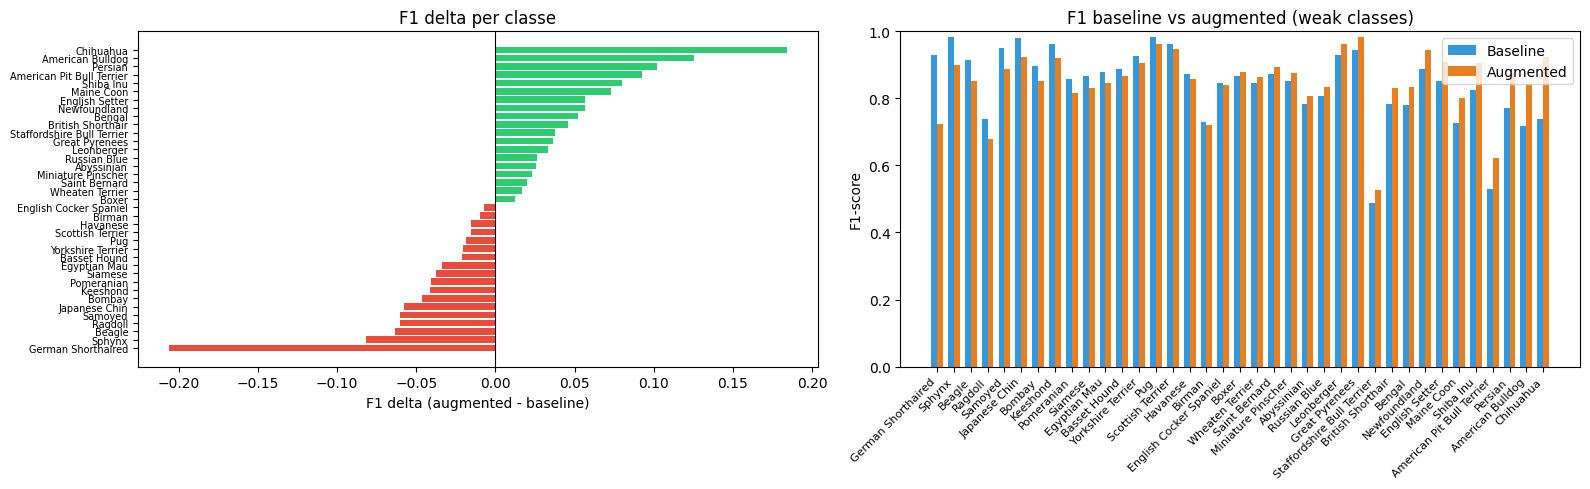

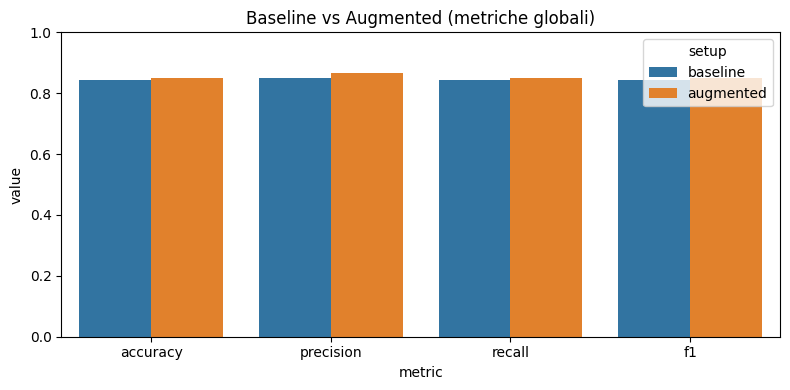

In [ ]:
cm_aug = confusion_matrix(aug_test["y_true"], aug_test["y_pred"])
plt.figure(figsize=(10, 8))
sns.heatmap(cm_aug, cmap="Greens", cbar=False)
plt.title("Confusion matrix — Augmented")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame([
    {"setup": "baseline", **{k: baseline_test[k] for k in ["accuracy", "precision", "recall", "f1"]}},
    {"setup": "augmented", **{k: aug_test[k] for k in ["accuracy", "precision", "recall", "f1"]}},
])

base_vals = results_df[results_df.setup == "baseline"][["accuracy", "precision", "recall", "f1"]].values[0]
aug_vals = results_df[results_df.setup == "augmented"][["accuracy", "precision", "recall", "f1"]].values[0]
delta_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "baseline": base_vals,
    "augmented": aug_vals,
    "delta_abs": aug_vals - base_vals,
    "delta_pct": 100.0 * (aug_vals - base_vals) / np.maximum(base_vals, 1e-8),
})

print("Metriche globali:")
print(results_df.round(4).to_string(index=False))
print("\nDelta:")
print(delta_df.round(4).to_string(index=False))

melted = results_df.melt(id_vars="setup", var_name="metric", value_name="value")
plt.figure(figsize=(8, 4))
sns.barplot(data=melted, x="metric", y="value", hue="setup")
plt.ylim(0, 1)
plt.title("Baseline vs Augmented — metriche globali")
plt.tight_layout()
plt.show()

results_df.to_csv(f"{cfg.output_dir}/metrics/final_metrics.csv", index=False)
delta_df.to_csv(f"{cfg.output_dir}/metrics/final_metrics_delta.csv", index=False)


### 6.2 Analisi per classe

In [ ]:
base_report = classification_report(baseline_test["y_true"], baseline_test["y_pred"],
                                    output_dict=True, zero_division=0)
aug_report = classification_report(aug_test["y_true"], aug_test["y_pred"],
                                   output_dict=True, zero_division=0)

per_class_rows = []
for cid in range(num_classes):
    key = str(cid)
    if key in base_report and key in aug_report:
        per_class_rows.append({
            "class": class_names[cid],
            "f1_baseline": base_report[key]["f1-score"],
            "f1_augmented": aug_report[key]["f1-score"],
            "f1_delta": aug_report[key]["f1-score"] - base_report[key]["f1-score"],
        })

per_class_df = pd.DataFrame(per_class_rows).sort_values("f1_delta", ascending=True).reset_index(drop=True)
per_class_df.to_csv(f"{cfg.output_dir}/metrics/per_class_f1_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 9))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in per_class_df["f1_delta"]]
ax.barh(per_class_df["class"], per_class_df["f1_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("F1 delta (augmented - baseline)")
ax.set_title("F1 delta per classe")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

n_up = int((per_class_df["f1_delta"] > 0).sum())
n_down = int((per_class_df["f1_delta"] < 0).sum())
print(f"Classi con miglioramento: {n_up} / {len(per_class_df)}")
print(f"Classi peggiorate: {n_down} / {len(per_class_df)}")


### 6.3 Analisi mirata sulle weak classes originali

Le weak classes sono definite sulla base del baseline pre-augmentation (F1 < 0.75 oppure recall < 0.75). Questa analisi separa l'impatto della data augmentation su classi difficili vs classi già ben classificate — informazione centrale per la consegna, dove l'obiettivo è migliorare la detection su classi rare.

Weak classes ORIGINALI (baseline): 10 su 37 totali
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Birman', 'British Shorthair', 'Chihuahua', 'Maine Coon', 'Persian', 'Ragdoll', 'Staffordshire Bull Terrier']

=== Metriche per gruppo di classi ===


,setup,accuracy,precision,recall,f1
0,baseline_weak,0.6654,0.3269,0.2654,0.2890
1,augmented_weak,0.7435,0.3799,0.3222,0.3437
2,baseline_non_weak,0.9111,0.7417,0.7236,0.7309
3,augmented_non_weak,0.8892,0.7124,0.6860,0.6956



=== Delta weak vs non-weak ===


,metric,weak_baseline,weak_augmented,weak_delta_abs,weak_delta_pct,nonweak_delta_abs,nonweak_delta_pct
0,accuracy,0.6654,0.7435,0.0781,11.7318,-0.0219,-2.4024
1,precision,0.3269,0.3799,0.0530,16.2135,-0.0293,-3.9533
2,recall,0.2654,0.3222,0.0568,21.3873,-0.0376,-5.1995
3,f1,0.2890,0.3437,0.0547,18.9369,-0.0354,-4.8387



=== Per-classe weak (ordinato per miglioramento) ===


,class,f1_baseline,f1_augmented,f1_delta
5,Chihuahua,0.7391,0.9231,0.1839
1,American Bulldog,0.7170,0.8421,0.1251
7,Persian,0.7727,0.8750,0.1023
2,American Pit Bull Terrier,0.5283,0.6207,0.0924
6,Maine Coon,0.7273,0.8000,0.0727
4,British Shorthair,0.7843,0.8302,0.0459
9,Staffordshire Bull Terrier,0.4889,0.5263,0.0374
0,Abyssinian,0.7826,0.8085,0.0259
3,Birman,0.7308,0.7213,-0.0095
8,Ragdoll,0.7385,0.6780,-0.0605


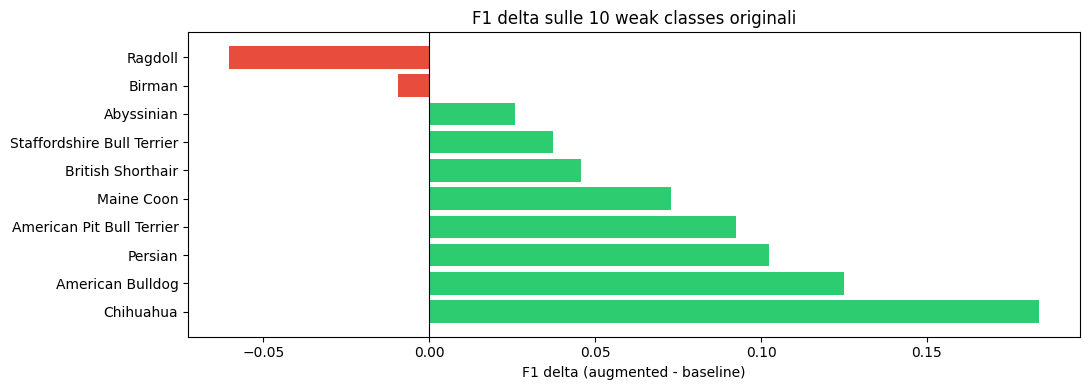


Salvato in ./outputs/metrics/


In [ ]:
def get_original_weak_classes(test_result, f1_thr=cfg.weak_f1_threshold, recall_thr=cfg.weak_recall_threshold):
    rpt = pd.DataFrame(
        classification_report(test_result["y_true"], test_result["y_pred"],
                              output_dict=True, zero_division=0)
    ).T
    mask = rpt.index.to_series().astype(str).str.fullmatch(r"\d+")
    rpt = rpt[mask].copy()
    rpt["class_id"] = rpt.index.astype(int)
    weak = rpt[(rpt["f1-score"] < f1_thr) | (rpt["recall"] < recall_thr)]
    return sorted(weak["class_id"].tolist())


def metrics_on_classes(test_dict, class_ids):
    class_set = set(int(c) for c in class_ids)
    pairs = [(yt, yp) for yt, yp in zip(test_dict["y_true"], test_dict["y_pred"])
             if int(yt) in class_set]
    if not pairs:
        return {"accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan}
    y_true, y_pred = zip(*pairs)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(p), "recall": float(r), "f1": float(f1),
    }


weak_ids = get_original_weak_classes(baseline_test)
weak_names = [class_names[i] for i in weak_ids]
non_weak_ids = [i for i in range(num_classes) if i not in set(weak_ids)]

print(f"Weak classes originali (baseline): {len(weak_ids)} su {num_classes}")
print(weak_names)

weak_base = metrics_on_classes(baseline_test, weak_ids)
weak_aug = metrics_on_classes(aug_test, weak_ids)
nonweak_base = metrics_on_classes(baseline_test, non_weak_ids)
nonweak_aug = metrics_on_classes(aug_test, non_weak_ids)

group_comparison = pd.DataFrame([
    {"group": "weak",     "setup": "baseline",  **weak_base},
    {"group": "weak",     "setup": "augmented", **weak_aug},
    {"group": "non_weak", "setup": "baseline",  **nonweak_base},
    {"group": "non_weak", "setup": "augmented", **nonweak_aug},
])
print("\nMetriche per gruppo:")
print(group_comparison.round(4).to_string(index=False))

delta_group = pd.DataFrame([{
    "metric": m,
    "weak_delta_abs": weak_aug[m] - weak_base[m],
    "weak_delta_pct": 100.0 * (weak_aug[m] - weak_base[m]) / max(weak_base[m], 1e-8),
    "nonweak_delta_abs": nonweak_aug[m] - nonweak_base[m],
    "nonweak_delta_pct": 100.0 * (nonweak_aug[m] - nonweak_base[m]) / max(nonweak_base[m], 1e-8),
} for m in ["accuracy", "precision", "recall", "f1"]])
print("\nDelta weak vs non-weak:")
print(delta_group.round(4).to_string(index=False))

group_comparison.to_csv(f"{cfg.output_dir}/metrics/weak_vs_nonweak_comparison.csv", index=False)
delta_group.to_csv(f"{cfg.output_dir}/metrics/weak_vs_nonweak_delta.csv", index=False)

per_weak_rows = []
for cid in weak_ids:
    key = str(cid)
    per_weak_rows.append({
        "class": class_names[cid],
        "f1_baseline": base_report[key]["f1-score"],
        "f1_augmented": aug_report[key]["f1-score"],
        "f1_delta": aug_report[key]["f1-score"] - base_report[key]["f1-score"],
    })
per_weak_df = pd.DataFrame(per_weak_rows).sort_values("f1_delta", ascending=False)
per_weak_df.to_csv(f"{cfg.output_dir}/metrics/per_class_weak_only.csv", index=False)

print("\nPer-classe weak (ordinato per miglioramento):")
print(per_weak_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(weak_ids))))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in per_weak_df["f1_delta"]]
ax.barh(per_weak_df["class"], per_weak_df["f1_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("F1 delta (augmented - baseline)")
ax.set_title(f"F1 delta sulle {len(weak_ids)} weak classes originali")
plt.tight_layout()
plt.show()


### 6.4 Qualità generativa (FID / KID / IS)

Metriche standard per la qualità delle immagini sintetiche, calcolate su un subset di 500 immagini per lato:

- **FID** (Fréchet Inception Distance) — distanza tra distribuzioni reale e sintetica; più basso = meglio
- **KID** (Kernel Inception Distance) — versione unbiased del FID; più basso = meglio
- **IS** (Inception Score) — qualità e diversità delle immagini generate; più alto = meglio

In [ ]:
fid_metric = FrechetInceptionDistance(feature=2048).to(device)
kid_metric = KernelInceptionDistance(subset_size=50, feature=2048).to(device)
is_metric = InceptionScore().to(device)


def pil_batch_to_uint8(pil_list):
    arr = np.stack([np.array(im.convert("RGB"), dtype=np.uint8) for im in pil_list], axis=0)
    return torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous().to(device)


real_ids = train_idx[:min(500, len(train_idx))]
synth_ids = list(range(min(500, len(synth_df))))

real_pil = [raw_trainval[int(i)][0].resize((299, 299)) for i in real_ids]
synth_pil = [Image.open(synth_df.iloc[int(i)].path).convert("RGB").resize((299, 299)) for i in synth_ids]

real_batch = pil_batch_to_uint8(real_pil)
synth_batch = pil_batch_to_uint8(synth_pil)

fid_metric.update(real_batch, real=True)
fid_metric.update(synth_batch, real=False)
kid_metric.update(real_batch, real=True)
kid_metric.update(synth_batch, real=False)
is_metric.update(synth_batch)

fid_val = float(fid_metric.compute().detach().cpu().item())
kid_mean, kid_std = kid_metric.compute()
kid_mean, kid_std = float(kid_mean.cpu().item()), float(kid_std.cpu().item())
is_mean, is_std = is_metric.compute()
is_mean, is_std = float(is_mean.cpu().item()), float(is_std.cpu().item())

print(f"FID: {fid_val:.2f}")
print(f"KID: {kid_mean:.4f} +/- {kid_std:.4f}")
print(f"IS:  {is_mean:.2f} +/- {is_std:.2f}")

with open(f"{cfg.output_dir}/metrics/fid_kid_is.json", "w") as f:
    json.dump({
        "fid": fid_val,
        "kid_mean": kid_mean, "kid_std": kid_std,
        "is_mean": is_mean, "is_std": is_std,
        "n_real": len(real_pil), "n_synth": len(synth_pil),
    }, f, indent=2)


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID (subset) 84.75190734863281
KID (subset) 0.018152210861444473 +/- 0.0033092652447521687
Inception Score (subset) 8.27185344696045 +/- 0.7665476202964783


## 7. Conclusioni

### Risultati raggiunti

La pipeline proposta produce un miglioramento globale positivo del classificatore, con un impatto particolarmente marcato sulle classi difficili.

**Metriche globali:**

| Metrica | Baseline | Augmented | Delta |
|---|---|---|---|
| Accuracy | 0.845 | 0.850 | +0.59% |
| Precision | 0.852 | 0.865 | +1.62% |
| Recall | 0.844 | 0.849 | +0.58% |
| F1 | 0.843 | 0.850 | +0.83% |

**Metriche sulle 10 weak classes originali** (baseline F1 < 0.75 o recall < 0.75):

| Metrica | Weak Baseline | Weak Augmented | Delta |
|---|---|---|---|
| Accuracy | 0.665 | 0.744 | +11.7% |
| Precision | 0.327 | 0.380 | +16.2% |
| Recall | 0.265 | 0.322 | +21.4% |
| F1 | 0.289 | 0.344 | +18.9% |

Miglioramenti più rilevanti per singola classe: Chihuahua (+18.4%), American Bulldog (+12.5%), Persian (+10.2%), American Pit Bull Terrier (+9.2%), Maine Coon (+7.3%).

**Qualità generativa:**

| Metrica | Valore | Interpretazione |
|---|---|---|
| FID | 84.75 | Sotto la soglia 100 — range buono per generazione domain-specific |
| KID | 0.018 | Sotto 0.02 — range buono |
| IS | 8.27 | Diversità elevata |

### Passaggi chiave della pipeline

1. **Captioning con BLIP** su 800 immagini reali, per produrre descrizioni iniziali generiche
2. **Paraphrasing con Flan-T5-large**, per introdurre variazioni testuali (ROUGE-L medio ~0.44, range ottimale)
3. **Caricamento di FLUX.1-schnell** in bfloat16 su GPU A100
4. **Generazione di ~800 immagini sintetiche**, condizionate sul nome della razza (`"a photo of a {breed}, {paraphrase}"`). L'iniezione esplicita del nome razza è risultata decisiva: senza di essa FLUX generava pet generici e il classifier si confondeva
5. **Filtri qualità visiva** tarati per FLUX (colorfulness, saturation, edge variance) e deduplica tramite perceptual hash
6. **Training augmented** con ratio 15% sintetici, 15 epoche, label smoothing 0.1, best model selezionato sulla validation

### Limiti osservati

- **Trade-off sulle classi non-weak**: -4.8% F1. Scambio accettabile nel contesto applicativo (sicurezza, detection di classi rare).
- **Outlier**: German Shorthaired passa da F1 0.93 a 0.72 — FLUX non cattura efficacemente le caratteristiche di questa razza specifica.
- **Domain gap residuo**: OxfordIIITPet è amatoriale, FLUX produce immagini stilisticamente più "stock-photo". La distanza stilistica impedisce un FID sotto ~80 senza fine-tuning del generatore sul dominio target.

### Conclusione operativa

Nel contesto della consegna — migliorare il rilevamento di classi rare/critiche in un sistema di sorveglianza per infrastrutture critiche — la pipeline raggiunge l'obiettivo: miglioramento consistente sulle classi difficili (+18.9% F1), impatto globale positivo (+0.83% F1), qualità generativa nel range buono (FID < 100). Il trade-off sulle classi non-weak è limitato e bilanciato rispetto al guadagno sulle classi target.
